In [11]:
import pandas as pd
from matplotlib import pyplot as plt

from pathlib import Path

from xaikd import constants
from datetime import datetime
from glob import glob

In [2]:
ARTIFACT_DIR = Path("../../artifacts/2025-02-s50/experiments/perf-curve/run1/")

In [3]:
def load_data(
    model, 
    layer, 
    dataset_name, 
    basis_name, 
    verbose=False, 
    ref_col="ref_accuracy",      
    stat_col="val_accuracy",
    logit_modifier="MultiClassLogOddWinning",
    data_size=0.1
):
    
    if "celeba" in model:
        path = ARTIFACT_DIR / model / dataset_name / f"data-size{data_size}" / layer / basis_name / "stats.csv"
    else:
        path = ARTIFACT_DIR / model / dataset_name / f"data-size{data_size}" / layer / basis_name / logit_modifier / "stats.csv"
    
    if verbose:
        print(f"path: {path}")
    files = sorted(list(glob(f"{path}")))
    
    arr_dfs = [pd.read_csv(f) for f in files]
    
    df = pd.concat(arr_dfs)

    assert (df.arch.values == model).all()
    assert len(df.basis_name.unique()) == 1
    assert len(df.layer.unique()) == 1
    
    df = df.groupby(["k"]).agg({
        ref_col: ["mean", "sem", "count"],
        stat_col: ["mean", "sem", "count"],
        "d": ["mean"]
    }).reset_index()
    
    return df
    
load_data(
    "celeba-resnet18-pretrained", "layer1", "celeba-attr0", "pca", verbose=True,
    ref_col="ref_auroc",
    stat_col="val_auroc",
)

path: ../../artifacts/2025-02-s50/experiments/perf-curve/run1/celeba-resnet18-pretrained/celeba-attr0/data-size0.1/layer1/pca/stats.csv


k ref_auroc           val_auroc               d
            mean sem count      mean sem count  mean
0    1  0.898797 NaN     1  0.553078 NaN     1  64.0
1    4  0.898797 NaN     1  0.628217 NaN     1  64.0
2    7  0.898797 NaN     1  0.617424 NaN     1  64.0
3   10  0.898797 NaN     1  0.740196 NaN     1  64.0
4   14  0.898797 NaN     1  0.841403 NaN     1  64.0
5   17  0.898797 NaN     1  0.860116 NaN     1  64.0
6   20  0.898797 NaN     1  0.874597 NaN     1  64.0
7   24  0.898797 NaN     1  0.881666 NaN     1  64.0
8   27  0.898797 NaN     1  0.885474 NaN     1  64.0
9   30  0.898797 NaN     1  0.890908 NaN     1  64.0
10  34  0.898797 NaN     1  0.893493 NaN     1  64.0
11  37  0.898797 NaN     1  0.894143 NaN     1  64.0
12  40  0.898797 NaN     1  0.894923 NaN     1  64.0
13  44  0.898797 NaN     1  0.896863 NaN     1  64.0
14  47  0.898797 NaN     1  0.897720 NaN     1  64.0
15  50  0.898797 NaN     1  0.898442 NaN     1  64.0
16  54  0.898797 NaN     1  0.898609 NaN     1  64.0
17  57  0.898797 NaN     1  0.898667 NaN     1  64.0
18  60  0.898797 NaN     1  0.899152 NaN     1  64.0
19  64  0.898797 NaN     1  0.898799 NaN     1  64.0

# ImageNet

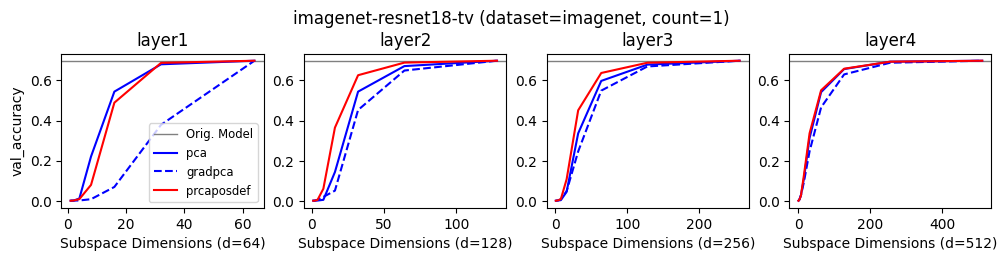

In [4]:
def alias(name):
    return {
        "prca-ablation-a-c": "prcaposdefv2",
    }.get(name, name)
    
def viz(
    dataset_name="imagenet",
    model_name="imagenet-resnet18-tv",
    arr_layers=["layer1", "layer2", "layer3", "layer4"], 
    arr_basis_names=[
        "pca",
        "gradpca",
        "prcaposdef",
        "prca-ablation-a-c",
        # "prcasortabs",
        # "prca",
    ],
    stat_col="val_accuracy",
    ref_col="val_accuracy",
    dict_color_ls={
        "pca":        ("blue", "-"),
        "gradpca":    ("blue", "--"),
        "prcaposdef": ("red",  "-"),
        "prca-ablation-a-c": ("red",  "--"),
    }
):
    ncols = len(arr_layers)
    plt.figure(figsize=(3*ncols, 2))
    
    
   
    for lix, layer in enumerate(arr_layers):
        plt.subplot(1, ncols, lix + 1)
        plt.title(layer)
        for bix, basis_name in enumerate(arr_basis_names):
            df = load_data(
                model=model_name,
                layer=layer,
                # todo: we should aggregate this over several datasets
                dataset_name=dataset_name,
                basis_name=basis_name,
                ref_col=ref_col,
                stat_col=stat_col
            )
            if bix == 0:
                plt.axhline(df[ref_col]["mean"].values[-1], ls="-", color="gray", lw=1, label="Orig. Model")
                count = df[ref_col]["count"].values[-1]
                
            d = int(df.d["mean"].values[-1])
            div = 4
            max_k = d
            selected = df.k <= max_k
            color, ls = dict_color_ls.get(basis_name, (None, None))

            arr_k = df["k"][selected]
            mean = df[stat_col]["mean"][selected]
            sem = df[stat_col]["sem"][selected]
            plt.plot(
                arr_k,
                mean,
                label=alias(basis_name),
                color=color,
                ls=ls,
                # marker=".",
            )
            plt.fill_between(
                arr_k,
                mean - sem,
                mean + sem,
                alpha=0.1,
                color=color
            )
            
        if lix == 0:
            plt.ylabel(stat_col)
            plt.legend(fontsize="small")
        
        plt.xlabel(f"Subspace Dimensions (d={d})")
    plt.suptitle(f"{model_name} (dataset={dataset_name}, count={count})", y=1.1)

viz(
    dataset_name="imagenet", 
    arr_basis_names=[
        "pca", "gradpca",
        "prcaposdef",
    ]
)

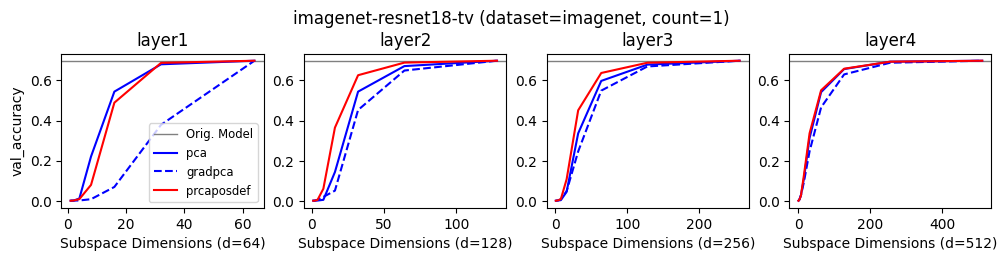

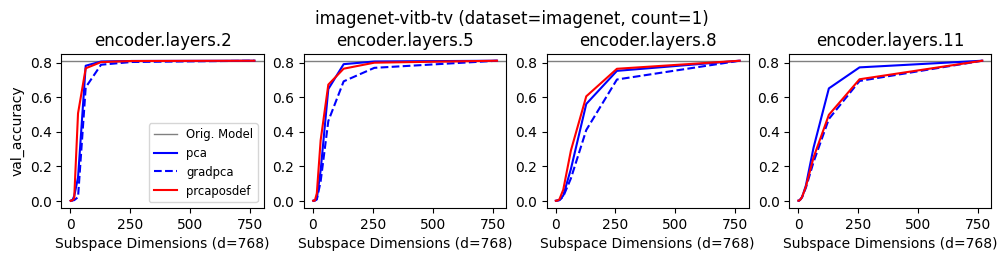

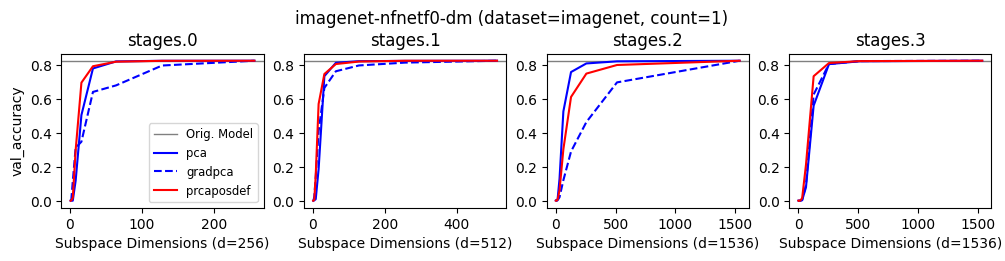

In [5]:
for model_name, arr_layers in [
    ("imagenet-resnet18-tv", ("layer1", "layer2", "layer3", "layer4")),
    ("imagenet-vitb-tv", ("encoder.layers.2", "encoder.layers.5", "encoder.layers.8", "encoder.layers.11")),
    ("imagenet-nfnetf0-dm", ("stages.0", "stages.1", "stages.2", "stages.3")),
]:
    
    viz(
        model_name=model_name,
        arr_layers=arr_layers,
        dataset_name="imagenet", 
        arr_basis_names=[
            "pca", "gradpca",
            "prcaposdef",
        ]
    )

# ImageNet-Butterfly

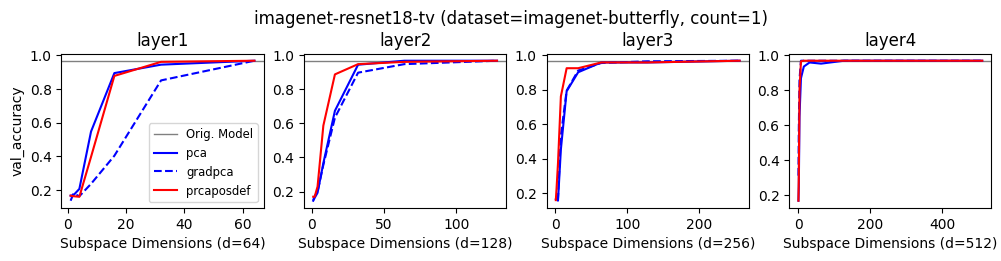

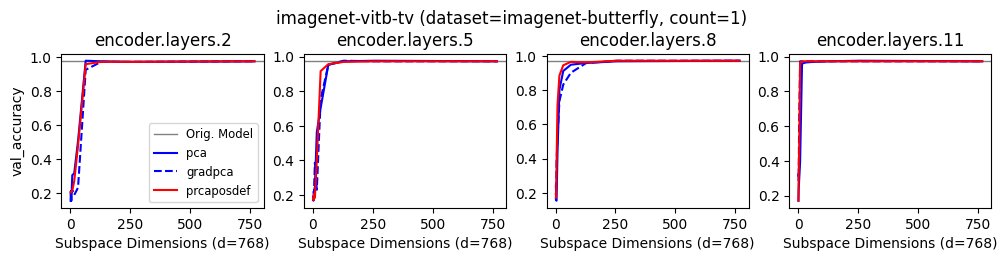

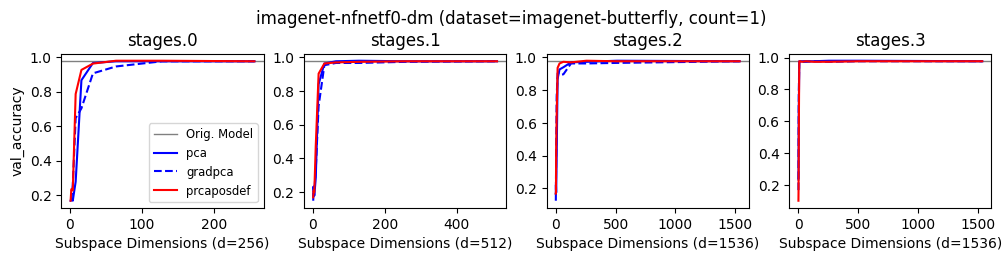

In [6]:
for model_name, arr_layers in [
    ("imagenet-resnet18-tv", ("layer1", "layer2", "layer3", "layer4")),
    ("imagenet-vitb-tv", (
        "encoder.layers.2", 
        "encoder.layers.5", 
        "encoder.layers.8", 
        "encoder.layers.11",
    )),
    ("imagenet-nfnetf0-dm", ("stages.0", "stages.1", "stages.2", "stages.3")),
]:
    
    viz(
        model_name=model_name,
        arr_layers=arr_layers,
        dataset_name="imagenet-butterfly", 
        arr_basis_names=[
            "pca", 
            "gradpca",
            "prcaposdef",
        ]
    )

# CelebA

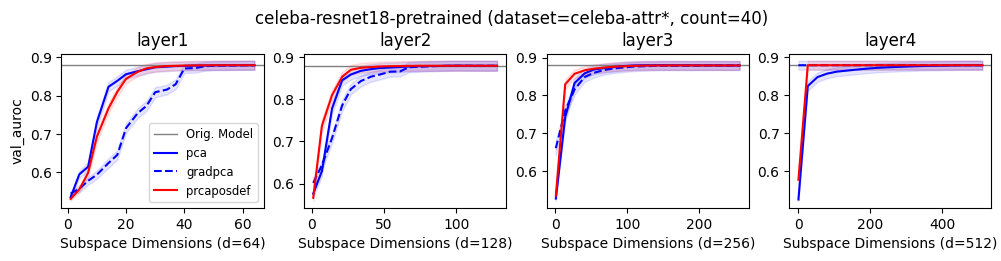

In [7]:
viz(
    model_name="celeba-resnet18-pretrained",
    dataset_name="celeba-attr*", 
    arr_basis_names=[
        "pca", "gradpca",
        "prcaposdef",
    ],
    ref_col="ref_auroc",
    stat_col="val_auroc",
)

In [ ]:
viz(
    model_name="celeba-resnet18-scratch",
    dataset_name="celeba-attr*", 
    arr_basis_names=[
        "pca", "gradpca",
        "prcaposdef",
    ],
    ref_col="ref_auroc",
    stat_col="val_auroc",
)

In [ ]:
print(f"finished at {datetime.now()}")